# Part 1 -- Classic XAI: From Penguins to Pitfalls

**XAI in Geoscience: From Feature Importance to Adjoint Sensitivities**
*Climademics Summer School, 2026-07-03*

This notebook is a guided, hands-on tour of four classic explainable-AI (XAI)
methods: **tree importance**, **permutation importance**, **partial
dependence / ICE**, and **SHAP**. For each method we ask three questions:

1. **What question does it answer?**
2. **Worked example** -- see it in action.
3. **Where does it mislead you?** -- every XAI method has blind spots, and
   knowing them is as important as knowing the method.

We use the [Palmer Penguins](https://allisonhorst.github.io/palmerpenguins/)
dataset throughout: a small, well-behaved, three-class classification problem
(predict penguin species from bill and flipper measurements) that lets us
focus entirely on the explanation methods rather than the modelling problem.

This notebook is fully self-contained -- it downloads the dataset and trains
its own models, no external files required. Runtime top-to-bottom is under a
few minutes on a free Colab CPU instance.

**Provenance.** This notebook is a rebuilt, corrected, and extended version of
material from the
[ml.recipes](https://github.com/JesperDramsch/ml-for-science-reproducibility-tutorial)
interpretability tutorial by Jesper Dramsch and Valerio Maggio (MIT License).
See `NOTICE` and `README.md` at the repository root for full attribution.
Notable changes from the original: the dataset is now loaded from the
`palmerpenguins` package instead of a pre-exported CSV, both models are
trained inline instead of loaded from a pre-trained file, a hardcoded
one-hot-encoding label bug is fixed, real ICE curves are added, and the SHAP
section is rebuilt on the modern matplotlib-native API.

---

## Setup

Run the cell below first. On Google Colab it installs the handful of packages
not preinstalled there (`shap`, `palmerpenguins`, `cmocean`); everywhere else
(local `uv` environment, Binder) it's a no-op since `pyproject.toml` already
pins these.

In [2]:
import sys

if "google.colab" in sys.modules:
    %pip install -q "shap==0.48.0" palmerpenguins cmocean

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 15.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 421.9/421.9 kB 26.1 MB/s eta 0:00:00


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import (
    PartialDependenceDisplay,
    permutation_importance,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.svm import SVC

# Colorblind-safe qualitative palette for every categorical plot below.
sns.set_theme(style="whitegrid", palette="colorblind")
RNG = np.random.RandomState(42)

## Load and prepare the data

We load Palmer Penguins from the `palmerpenguins` package, with `seaborn`'s
bundled copy as a fallback if the package or its data file is unreachable
(e.g. a restrictive network). Both sources use the same column names.

We do the minimal cleaning the original analysis relied on: drop rows with
any missing measurement (a handful of penguins have unrecorded sex or
measurements) and keep the four features used throughout this notebook: three
numeric bill/flipper measurements, and `sex` as the one categorical feature.

In [4]:
try:
    from palmerpenguins import load_penguins

    penguins = load_penguins()
except Exception:
    penguins = sns.load_dataset("penguins")

penguins = penguins.dropna().reset_index(drop=True)

num_features = ["bill_length_mm", "bill_depth_mm", "flipper_length_mm"]
cat_features = ["sex"]
features = num_features + cat_features
target = "species"

X = penguins[features]
y = penguins[target]

print(f"{len(penguins)} penguins after dropping missing values")
penguins.head()

# print(penguins.iloc[200:205])

333 penguins after dropping missing values


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007
3,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007
4,Adelie,Torgersen,39.3,20.6,190.0,3650.0,male,2007


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, stratify=y, train_size=0.7, random_state=42
)
print(f"train: {len(X_train)}, test: {len(X_test)}")

train: 233, test: 100


## Train the two models we'll explain

We train two classifiers on identical data through an identical
preprocessing pipeline (scale the numeric features, one-hot encode `sex`):
a **Random Forest** (has built-in tree importance, so we can compare it
against model-agnostic methods) and a **Support Vector Classifier** (no
built-in importances at all -- it can *only* be explained with
model-agnostic methods like permutation importance and SHAP). Seeing both
methods applied to a model that "cheats" via built-in importance, and one
that can't, is what Section 1 vs Section 2 below sets up.

In [18]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_features),
    ]
)

# Random Forest
rf_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", RandomForestClassifier(random_state=42)),
    ]
)
rf_model.fit(X_train, y_train)

# Support Vector Classifier
svc_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", SVC(random_state=42, probability=True)),
    ]
)
svc_model.fit(X_train, y_train)

print(f"Random Forest test accuracy: {rf_model.score(X_test, y_test):.3f}")
print(f"SVM test accuracy:           {svc_model.score(X_test, y_test):.3f}")

Random Forest test accuracy: 1.000
SVM test accuracy:           1.000


---
## 1. Tree (impurity) importance

**The question it answers:** *"Which features did this specific tree-based
model lean on internally to reduce prediction error?"* It's read directly
off the fitted model -- no extra computation needed, which makes it
essentially free.

**A historical pitfall, fixed here.** An earlier version of this analysis
(the ml.recipes tutorial this notebook builds on) extracted the importance
values like this:

```python
# DON'T DO THIS -- fragile, silently wrong if column order changes:
pd.Series(
    rf.feature_importances_,
    index=num_features + ["Female", "Male"],   # <- hardcoded!
).plot.bar()
```

This *happened* to work only because `OneHotEncoder`'s default alphabetical
ordering of `Sex` produced exactly `["Female", "Male"]` in that order. Change
the category spelling, add a third category, or reorder the pipeline, and
the labels silently point at the wrong bars -- with no error, just a wrong
plot. Below we derive the labels programmatically instead.

bill_length_mm       0.425639
flipper_length_mm    0.316407
bill_depth_mm        0.240550
sex_male             0.009596
sex_female           0.007809
dtype: float64


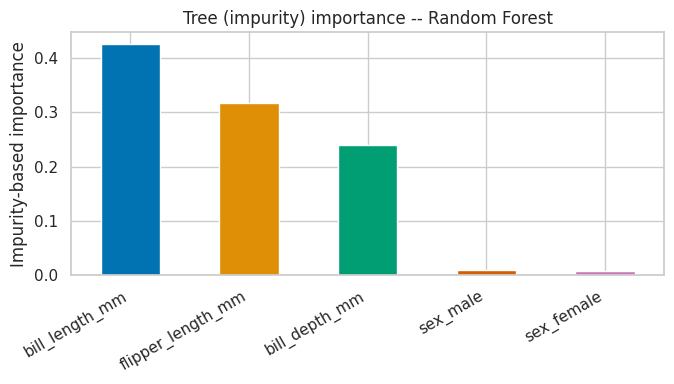

In [7]:
feature_names_out = rf_model.named_steps["preprocessor"].get_feature_names_out()
# print(feature_names_out)
feature_names_out = [n.split("__", 1)[1] for n in feature_names_out]  # drop num__/cat__ prefix
# print(feature_names_out)
importances = rf_model.named_steps["classifier"].feature_importances_
# print(importances)

tree_importance = pd.Series(importances, index=feature_names_out).sort_values(ascending=False)
print(tree_importance)

fig, ax = plt.subplots(figsize=(7, 4))
tree_importance.plot.bar(ax=ax, color=sns.color_palette("colorblind"))
ax.set_ylabel("Impurity-based importance")
ax.set_title("Tree (impurity) importance -- Random Forest")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

**Where it misleads you.**

- **One-hot splitting**: `sex` was a single categorical feature, but after
  one-hot encoding it shows up as *two* separate bars (`sex_female`,
  `sex_male`). Its "true" importance as a single concept is the *sum* of
  those two bars, not either one alone -- a feature with many categories
  gets its importance artificially spread thin across many bars, making it
  look individually less important than a numeric feature of equal real
  predictive value. This is the **cardinality bias** of impurity importance.
- **Correlated features** split credit between themselves in the same way,
  for the same underlying reason (a tree only needs to split on *one* of two
  correlated features to capture their shared signal).
- It only reflects importance **on the training data the trees were grown
  on** -- it says nothing about generalisation. A feature that happens to
  perfectly separate a few noisy training examples (overfitting) can rank
  highly here despite being useless on new data. Exercise 1 makes this
  concrete.

### Exercise 1: does impurity importance get fooled by pure noise?

**Task:** add a random-noise feature to the training data (a column of
`np.random.normal` values, completely unrelated to species), retrain the
Random Forest, and re-run tree importance.

**Success criteria:** the noise feature appears in the bar chart with
**nonzero** importance -- despite being pure random noise. Can you explain
why, in a sentence, before reading Section 2?

*Hint:* `rng = np.random.RandomState(42)` and
`rng.normal(size=len(X_train))` give you a reproducible noise column. You'll
need to rebuild the `ColumnTransformer`/`Pipeline` with `noise` added to
`num_features`, the same way `rf_model` was built above.

Random Forest test accuracy: 1.000
['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'noise', 'sex_female', 'sex_male']
bill_length_mm       0.420534
flipper_length_mm    0.288710
bill_depth_mm        0.243486
noise                0.029955
sex_male             0.008832
sex_female           0.008482
dtype: float64


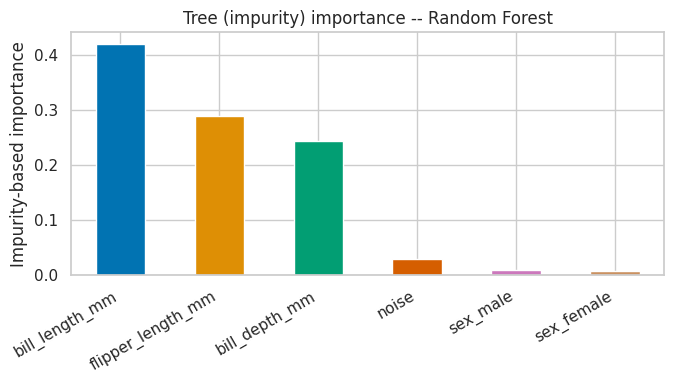

In [8]:
# TODO(exercise 1): add a "noise" column to X_train/X_test, retrain a Random
# Forest pipeline on the extended feature set, and plot its tree importance.
# Success criteria: the noise feature has nonzero importance.

# Starter scaffold (already runs as-is) -- extend it below:
X_train_noisy = X_train.copy()
X_test_noisy = X_test.copy()
X_train_noisy["noise"] = RNG.normal(size=len(X_train_noisy))
X_test_noisy["noise"] = RNG.normal(size=len(X_test_noisy))

# TODO: build num_features_noisy = num_features + ["noise"], a new
# ColumnTransformer/Pipeline using it, fit on X_train_noisy/y_train, and
# plot tree importance the same way as the cell above.

num_features_noisy = num_features + ["noise"]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_features_noisy),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_features),
    ]
)


# Random Forest
rf_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", RandomForestClassifier(random_state=42)),
    ]
)
rf_model.fit(X_train_noisy, y_train)

print(f"Random Forest test accuracy: {rf_model.score(X_test_noisy, y_test):.3f}")


feature_names_out = rf_model.named_steps["preprocessor"].get_feature_names_out()
feature_names_out = [n.split("__", 1)[1] for n in feature_names_out]  # drop num__/cat__ prefix
print(feature_names_out)
importances = rf_model.named_steps["classifier"].feature_importances_

tree_importance = pd.Series(importances, index=feature_names_out).sort_values(ascending=False)
print(tree_importance)

fig, ax = plt.subplots(figsize=(7, 4))
tree_importance.plot.bar(ax=ax, color=sns.color_palette("colorblind"))
ax.set_ylabel("Impurity-based importance")
ax.set_title("Tree (impurity) importance -- Random Forest")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

ANSWER: The key is that in some cases the introduced noise happens to explains the sex difference, just by chance. And therefore the computed importance is bigger than zero.

GEMINI: The noise feature appears in the bar chart with non-zero importance because impurity-based importance measures how much each feature contributes to reducing the impurity of the nodes in a decision tree (or ensemble of trees, like a Random Forest). Even with a purely random noise feature, it is statistically probable that, by chance, some splits on this noise feature will result in a slight reduction in impurity for some of the trees in the forest. The model is essentially finding spurious correlations within the training data, however weak, and will utilize them if they lead to an improvement in its internal impurity metric. Since the importance is an average over many trees, even small, random contributions can sum up to a non-zero value, highlighting that impurity importance can be fooled by pure noise, especially without regularization or deeper analysis

---
## 2. Permutation importance

**The question it answers:** *"If I scramble this one feature's values (and
only this one), how much worse does the model's performance get?"* Unlike
tree importance, this works for **any** fitted model -- it only needs
`.predict`/`.score`, not access to the model's internals. That's why it's
called **model-agnostic**.

Because permutation is random, we repeat it (`n_repeats`) and look at the
*spread* of results, not just a single number -- giving us an honest sense of
uncertainty that impurity importance doesn't offer at all.

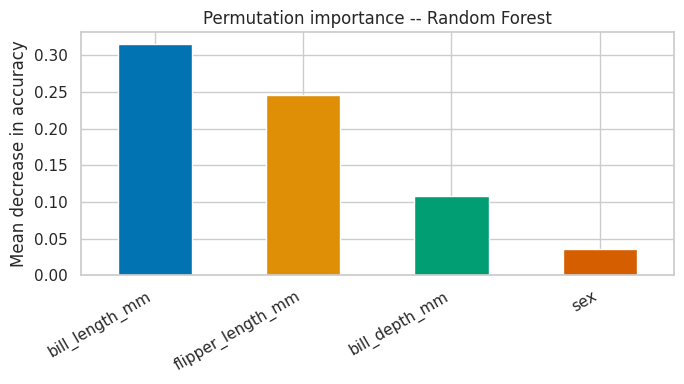

In [13]:
rf_perm = permutation_importance(rf_model, X_train, y_train, n_repeats=10, random_state=42)

perm_importance = pd.Series(rf_perm.importances_mean, index=features).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(7, 4))
perm_importance.plot.bar(ax=ax, color=sns.color_palette("colorblind"))
ax.set_ylabel("Mean decrease in accuracy")
ax.set_title("Permutation importance -- Random Forest")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

Notice `sex` is now a **single** bar -- permutation importance operates on
the raw, un-encoded features, so it doesn't suffer from the one-hot
splitting problem in Section 1 at all. This alone is often reason enough to
prefer it.

Now the same thing on the SVM, which has no built-in
importance of any kind. Permutation importance is the only importance method
available to it directly (SHAP, in Section 4, is the other option). We also
switch to a boxplot here to show all 10 repeats, not just their mean.

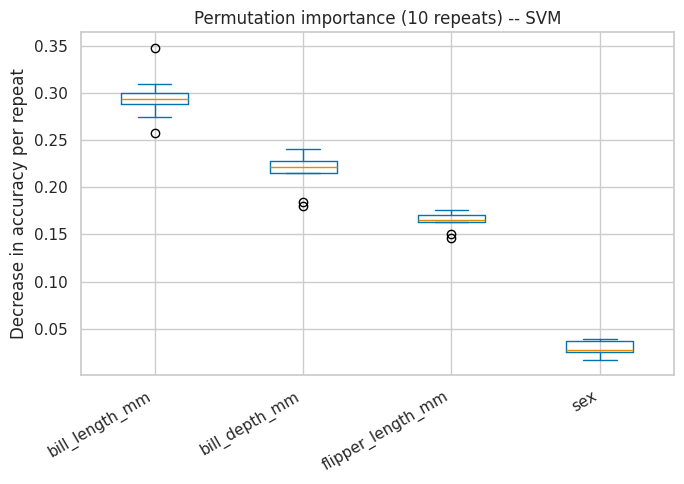

In [14]:
svc_perm = permutation_importance(svc_model, X_train, y_train, n_repeats=10, random_state=42)

fig, ax = plt.subplots(figsize=(7, 5))
pd.DataFrame(svc_perm.importances.T, columns=features).plot.box(ax=ax, color=dict(boxes="C0", medians="C1"))
ax.set_ylabel("Decrease in accuracy per repeat")
ax.set_title("Permutation importance (10 repeats) -- SVM")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

### The flagship figure: train vs. test, for both models at once

A model that overfits will often show **high permutation importance on the
training set that doesn't hold up on the test set** -- because the model
learned to rely on patterns specific to the training data. Comparing
train-set and test-set permutation importance side by side is a fast,
visual overfitting check, and comparing two different model families in the
same figure tells you whether a feature's importance is a property of the
*data* or an artifact of one particular *model*.

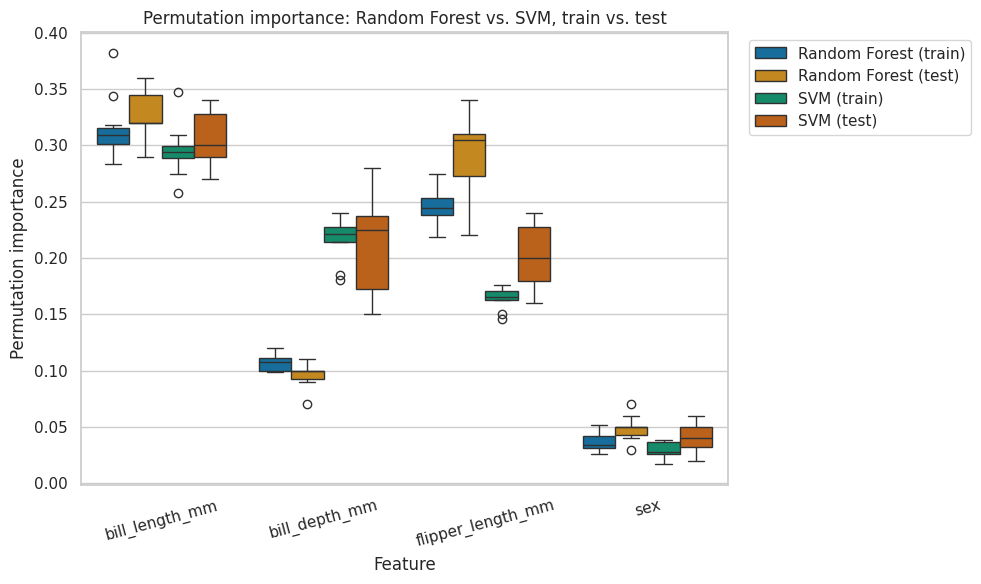

In [15]:
rf_perm_train = permutation_importance(rf_model, X_train, y_train, n_repeats=10, random_state=42)
rf_perm_test = permutation_importance(rf_model, X_test, y_test, n_repeats=10, random_state=42)
svc_perm_train = permutation_importance(svc_model, X_train, y_train, n_repeats=10, random_state=42)
svc_perm_test = permutation_importance(svc_model, X_test, y_test, n_repeats=10, random_state=42)


def _to_long_df(result, group_label):
    df = pd.DataFrame(result.importances.T, columns=features)
    df["Group"] = group_label
    return df


combined = pd.concat(
    [
        _to_long_df(rf_perm_train, "Random Forest (train)"),
        _to_long_df(rf_perm_test, "Random Forest (test)"),
        _to_long_df(svc_perm_train, "SVM (train)"),
        _to_long_df(svc_perm_test, "SVM (test)"),
    ]
)
melted = pd.melt(combined, id_vars=["Group"], var_name="Feature", value_name="Permutation importance")

fig, ax = plt.subplots(figsize=(10, 6))
sns.boxplot(x="Feature", y="Permutation importance", hue="Group", data=melted, palette="colorblind", ax=ax)
ax.set_title("Permutation importance: Random Forest vs. SVM, train vs. test")
plt.xticks(rotation=15)
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

**Where it misleads you.**

- **Correlated features share the blame**, just like in tree importance: if
  two features carry overlapping signal, scrambling either one alone barely
  hurts performance (the model still has the other one to lean on), so both
  can look artificially *unimportant* even though the pair together matters
  a lot.
- **It's expensive.** Every repeat re-scores the model on the *entire*
  dataset once per feature -- fine here with a few hundred penguins, painful
  with large datasets or slow models.
- **It answers "how much does performance drop", not "why".** Two features
  can have identical permutation importance for entirely different reasons.

### Exercise 2: does permutation importance resist the noise trap?

**Task:** repeat the Exercise 1 noise-feature experiment (you'll have
`X_train_noisy`/`X_test_noisy` already if you did Exercise 1, or rebuild
them), but this time run **permutation importance** instead of tree
importance, on the Random Forest.

**Success criteria:** compare the noise feature's permutation importance to
its tree importance from Exercise 1. Are they still both "nonzero" in a
way that would fool you? Write one sentence explaining the disagreement
(or agreement) before moving on.

Random Forest test accuracy: 1.000


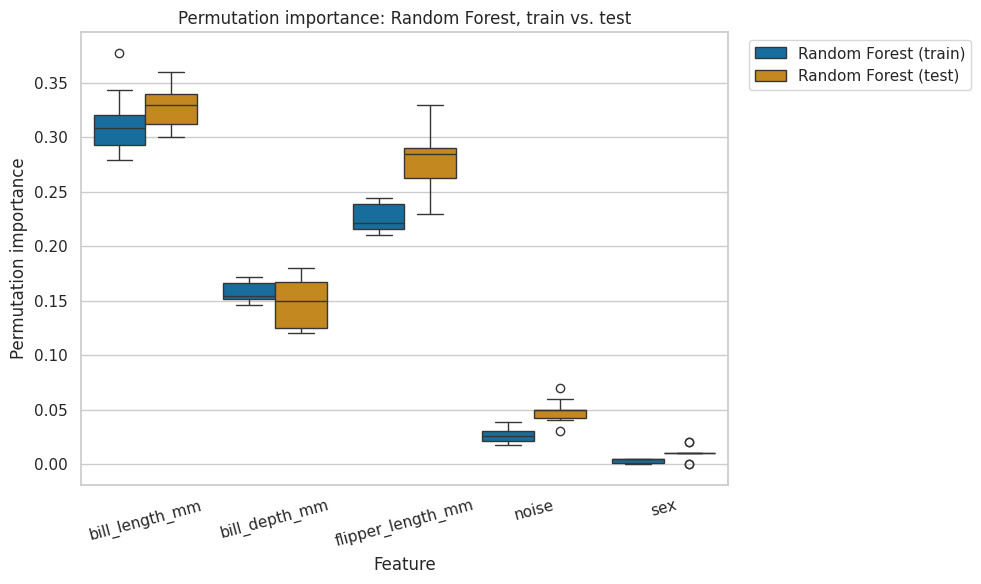

In [32]:
# TODO(exercise 2): rebuild a Random Forest pipeline on the noisy feature set
# (reuse X_train_noisy/X_test_noisy from Exercise 1) and run
# permutation_importance on it. Compare the "noise" feature's value here to
# its tree-importance value in Exercise 1.

# Starter scaffold (already runs as-is) -- extend it below:
num_features_noisy = num_features + ["noise"]
features_noisy = num_features_noisy + cat_features

# TODO: build the ColumnTransformer/Pipeline for num_features_noisy, fit it
# on X_train_noisy/y_train, then call permutation_importance(...) on it and
# plot the result the same way as the RF permutation importance cell above.

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_features_noisy),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_features),
    ]
)


# Random Forest
rf_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", RandomForestClassifier(random_state=42)),
    ]
)
rf_model.fit(X_train_noisy, y_train)

print(f"Random Forest test accuracy: {rf_model.score(X_test_noisy, y_test):.3f}")

# Permutation importance test
rf_perm_train = permutation_importance(rf_model, X_train_noisy, y_train, n_repeats=10, random_state=42)
rf_perm_test = permutation_importance(rf_model, X_test_noisy, y_test, n_repeats=10, random_state=42)


def _to_long_df(result, group_label):
    df = pd.DataFrame(result.importances.T, columns=features_noisy)
    df["Group"] = group_label
    return df


combined = pd.concat(
    [
        _to_long_df(rf_perm_train, "Random Forest (train)"),
        _to_long_df(rf_perm_test, "Random Forest (test)"),
    ]
)
melted = pd.melt(combined, id_vars=["Group"], var_name="Feature", value_name="Permutation importance")

fig, ax = plt.subplots(figsize=(10, 6))
sns.boxplot(x="Feature", y="Permutation importance", hue="Group", data=melted, palette="colorblind", ax=ax)
ax.set_title("Permutation importance: Random Forest, train vs. test")
plt.xticks(rotation=15)
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


ANSWER: It seems to still be non zero, but in this case we can make use of the variance, max and min. They show smaller variance compared to the 3 characteristics.

This points out to overfitting, the model is tanking into account the noise, when using the test dataset its importance increases.


GEMINI: Permutation importance for the noise feature is  still non-zero, even for a purely random feature. This is because, by chance, permuting a random feature's values can sometimes lead to a slight decrease in the model's performance on the training data. The model might have found and exploited some spurious correlations with this noise during training, leading to a minor drop in accuracy when those random patterns are disrupted.

However, the key difference from tree importance, and a major strength of permutation importance, comes from comparing its performance on the training set versus the test set. While the noise feature might show a small non-zero importance on the training set (due to those chance correlations), its importance on the test set (unseen data) will typically be significantly closer to zero, or even negative (if the model's random guess worked better by chance before permutation). This clear discrepancy between training and testing permutation importance for the noise feature is a strong indicator that it's not a truly predictive feature, allowing us to 'resist the noise trap' more effectively than tree importance, which is solely based on training data metrics.



---
## 3. Partial dependence (PDP) and individual conditional expectation (ICE)

**The question it answers:** *"On average, how does the model's predicted
probability change as I vary one feature, holding everything else fixed?"*
That's the **partial dependence plot (PDP)** -- it shows an *averaged*
response curve. **ICE curves** show the same thing but *per individual data
point*, before averaging -- so you can see whether that average curve is
actually representative of everyone, or an average of very different
individual behaviours.

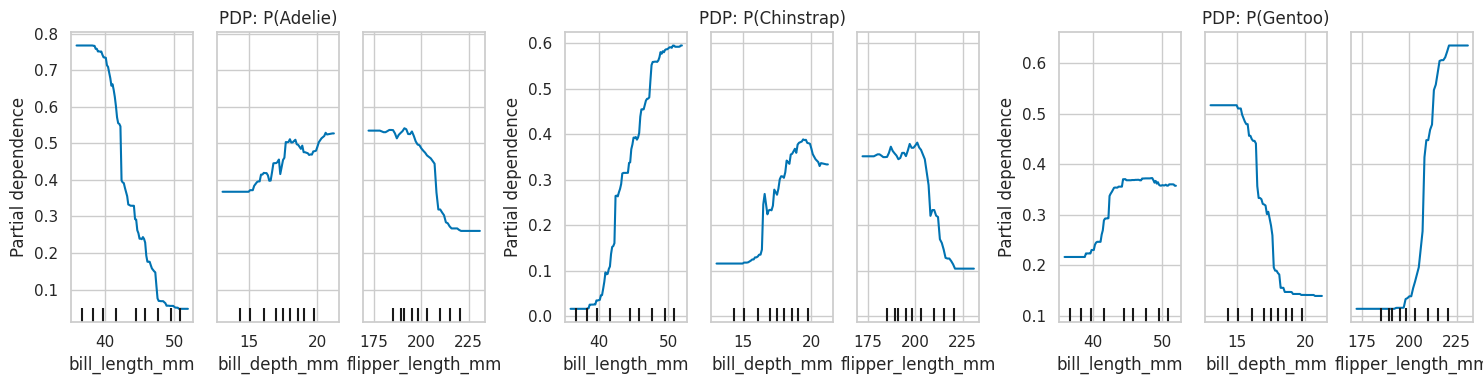

In [19]:
fig, axs = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
for ax, species in zip(axs, rf_model.classes_):
    PartialDependenceDisplay.from_estimator(
        rf_model, X_train, num_features, target=species, ax=ax
    )
    ax.set_title(f"PDP: P({species})")
plt.tight_layout()
plt.show()

Now let's add ICE curves for one feature/class combination, to see what the
averaging in the plots above was hiding.

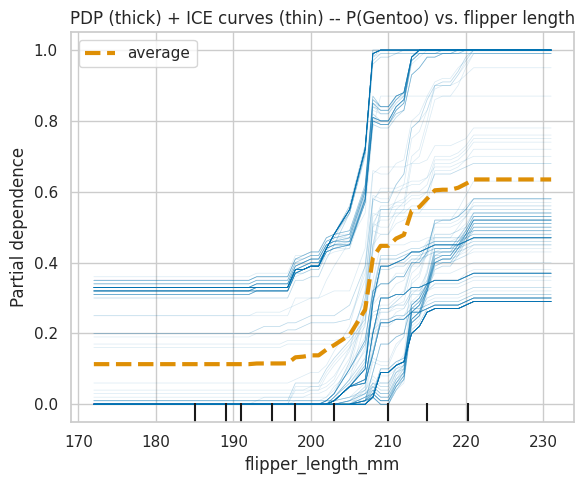

In [31]:
fig, ax = plt.subplots(figsize=(6, 5))
PartialDependenceDisplay.from_estimator(
    rf_model,
    X_train,
    ["flipper_length_mm"],
    target="Gentoo",
    kind="both",
    ax=ax,
    ice_lines_kw={"color": "C0", "alpha": 0.15},
    pd_line_kw={"color": "C1", "linewidth": 3},
)
ax.set_title("PDP (thick) + ICE curves (thin) -- P(Gentoo) vs. flipper length")
plt.tight_layout()
plt.show()



**Where it misleads you.**

- **Averaging hides interactions.** The thick PDP line in the plot above is
  the *average* of all the thin ICE lines. If some penguins' curves slope
  up while others slope down (an interaction with another feature, e.g. bill
  shape), the average can look flat or mild even though no single penguin
  actually experiences that flat response -- Simpson's-paradox-style.
- **Extrapolation into empty feature space.** A PDP evaluates the model at
  every observed value of the feature of interest, combined with every
  *other* observed row's remaining features -- some of those combinations
  may not resemble any real penguin (e.g. a very long bill paired with a
  very short flipper). The model still produces a prediction there, but it's
  extrapolating into a region with no training data to support it, and the
  PDP curve doesn't warn you.
- Both PDP and ICE only vary **one (or two) features at a time**, by
  construction -- they can't tell you about higher-order interactions
  directly.

### Exercise 3: find a penguin whose ICE curve disagrees with the average

**Task:** add ICE curves for `bill_depth_mm` (pick whichever species class
you like as the `target`) and find an individual penguin whose ICE curve
diverges noticeably from the average PDP line.

**Success criteria:** identify (by row index or by printing its features) at
least one penguin whose individual curve visibly disagrees with the thick
average line, and write a one-sentence hypothesis for *why* that penguin
behaves differently (hint: look at its *other* feature values).

*Hint:* `PartialDependenceDisplay.from_estimator(..., kind="both")` returns a
`display` object; its `.pd_results[0]["individual"][0]` array holds every
sampled row's ICE curve values, and `.pd_results[0]["grid_values"][0]` holds
the corresponding x-axis grid -- useful if you want to find the
most-diverging curve programmatically rather than just eyeballing the plot.

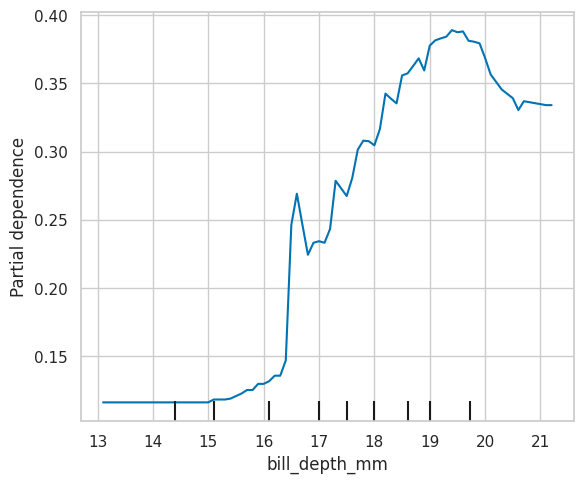

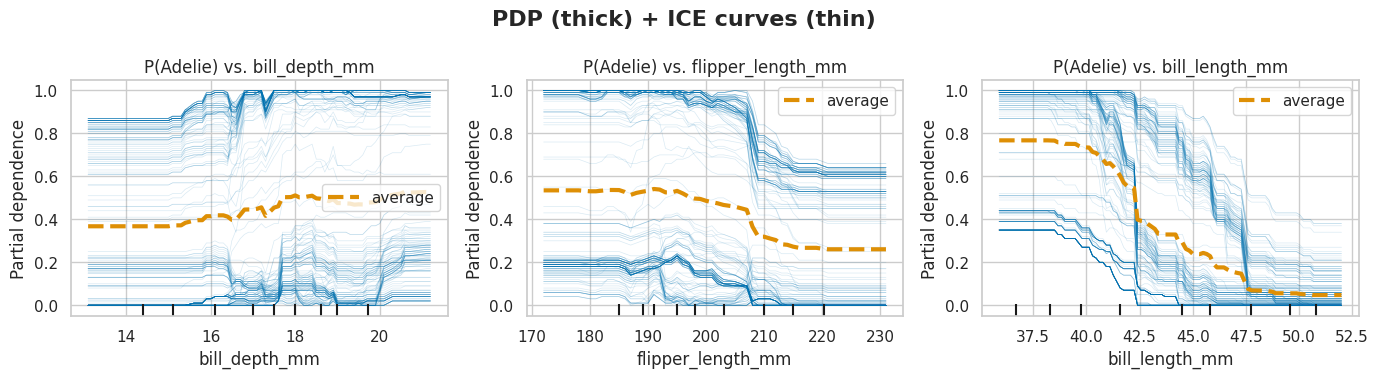

In [30]:
# TODO(exercise 3): plot PDP+ICE (kind="both") for "bill_depth_mm" the same
# way as the flipper_length_mm example above, then find an individual
# penguin (a single ICE line) whose curve diverges from the average PDP
# line. Print that penguin's row from X_train to see what makes it unusual.

# Starter scaffold (already runs as-is) -- extend it below:
fig, ax = plt.subplots(figsize=(6, 5))
PartialDependenceDisplay.from_estimator(
    rf_model,
    X_train,
    ["bill_depth_mm"],
    target="Chinstrap",
    kind="average",  # TODO: change to "both" once you're ready to see ICE curves
    ax=ax,
)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(18/1.3, 5/1.3))
features = ["bill_depth_mm", "flipper_length_mm", "bill_length_mm"]

for i, feature in enumerate(features):
    PartialDependenceDisplay.from_estimator(
        rf_model,
        X_train,
        [feature],
        target="Adelie",
        kind="both",
        ax=axes[i],
        ice_lines_kw={"color": "C0", "alpha": 0.15},
        pd_line_kw={"color": "C1", "linewidth": 3},
    )
    axes[i].set_title(f"P(Adelie) vs. {feature}")

fig.suptitle("PDP (thick) + ICE curves (thin)", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()


ANSWER: In the case of Adelie penguins, average curve PDP shows that bill depth seems to not affect the predicting of penguins being Adelie.
ICE curves shows two different groups of peguins:
- Top Subgroup: These penguins have an incredibly high baseline probability (80%+) of being Adelie, which pushes to nearly 100% as bill depth increases.
- Bottom Subgroup: These penguins stay trapped near a 0% to 20% probability, regardless of bill depth.
- The Averaging Trap: Because one group is near 100% and the other is near 0%, the orange PDP line splits the difference and walks right down the useless middle (~50%).

Consequence of the strong interaction between the two other factors and bill depth. No single penguin actually exhibits the average probability shown by the PDP.

Could happen if the beak is determining for males, but for females e.g.

---
## 4. SHAP

**The question it answers:** *"For this one prediction, how much did each
feature push the output away from the average prediction?"* (local
explanation) -- and, aggregated across many predictions, *"which features
matter most overall, and in which direction?"* (global explanation). SHAP is
grounded in cooperative game theory (Shapley values): each feature is
treated as a "player" contributing to the "payout" (the prediction), and
credit is split in the mathematically unique way that satisfies a set of
fairness axioms.

We train a dedicated Random Forest on the three numeric features only (as
the original ml.recipes tutorial did) -- this keeps `TreeExplainer` fast and
exact, and sidesteps needing a categorical-aware masker. We give it a
distinct name, `shap_rf`, to avoid confusing it with `rf_model` above (which
includes `sex` and is used everywhere else in this notebook).

**Modernisation note.** The original tutorial used `shap.initjs()` and
`shap.force_plot(...)`, which render interactive JavaScript widgets. Those
break silently in static exports, PDFs, and some Colab download paths. We
use the matplotlib-native API instead (`shap.plots.waterfall`,
`shap.plots.beeswarm`), pinned against `shap==0.48.0` -- the API for
multiclass output changed across shap versions (older versions returned a
list of per-class arrays; 0.48.0 returns a single `Explanation` with shape
`(n_samples, n_features, n_classes)`, sliced as `shap_values[sample, :,
class]`), so if you use a different shap version, check the release notes
before assuming this code works unchanged.

In [43]:
shap_rf = RandomForestClassifier(random_state=42)
shap_rf.fit(X_train[num_features], y_train)
print(f"shap_rf test accuracy: {shap_rf.score(X_test[num_features], y_test):.3f}")
print(f"classes: {list(shap_rf.classes_)}")

explainer = shap.Explainer(shap_rf)
shap_values = explainer(X_test[num_features])
print(f"shap_values.values.shape: {shap_values.values.shape}  (n_samples, n_features, n_classes)")

shap_rf test accuracy: 0.990
classes: ['Adelie', 'Chinstrap', 'Gentoo']
shap_values.values.shape: (100, 3, 3)  (n_samples, n_features, n_classes)


### Local: why did the model predict *this* species for *this* penguin?

A waterfall plot for a single test-set penguin, for its predicted class:
starting from the average predicted probability (`E[f(X)]`), each feature
pushes the probability up (red) or down (blue) until we reach the model's
actual output for this one penguin.

Penguin #88: true species = Adelie, predicted = Adelie


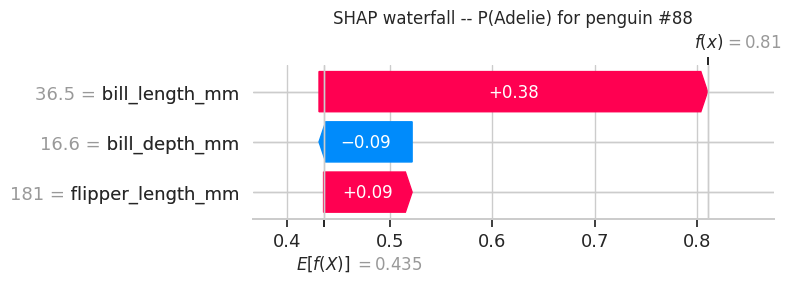

In [42]:
sample_idx = 88
predicted_class = shap_rf.predict(X_test[num_features].iloc[[sample_idx]])[0]
class_idx = list(shap_rf.classes_).index(predicted_class)

print(f"Penguin #{sample_idx}: true species = {y_test.iloc[sample_idx]}, predicted = {predicted_class}")
shap.plots.waterfall(shap_values[sample_idx, :, class_idx], show=False)
plt.title(f"SHAP waterfall -- P({predicted_class}) for penguin #{sample_idx}")
plt.tight_layout()
plt.show()

### Global: which features matter most overall, and how?

A beeswarm plot summarises every test-set penguin at once: each dot is one
penguin, its position shows that feature's SHAP value (impact on the
predicted probability for one class), and its colour shows whether that
penguin's *own* feature value was high or low.

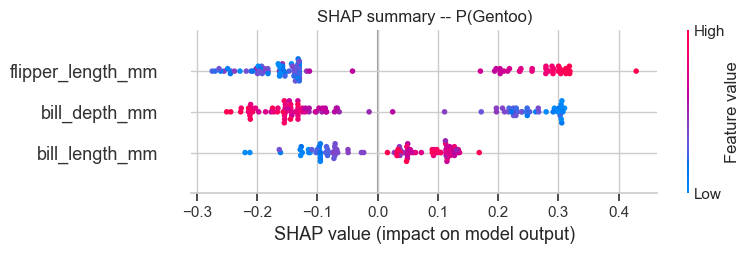

In [ ]:
class_idx = list(shap_rf.classes_).index("Gentoo")

shap.plots.beeswarm(shap_values[:, :, class_idx], show=False)
plt.title("SHAP summary -- P(Gentoo)")
plt.tight_layout()
plt.show()

**Where it misleads you.**

- **Explaining the model is not explaining the world.** SHAP tells you
  exactly how *this fitted model* used each feature -- it says nothing about
  causation, and nothing about whether the model itself is a good
  description of penguin biology. If `sex` correlates with body size in this
  dataset (it does, penguins show sexual size dimorphism), a model could
  lean on `sex` as a *proxy* for size-related traits it hasn't been given
  directly. SHAP would faithfully report "`sex` mattered" -- correctly
  describing the model's behaviour, while telling you nothing about *why*
  sex and species are correlated in the real world.
- **Background/reference data matters.** SHAP values are relative to a
  baseline distribution (here, the training data) -- change the reference
  set and the same prediction can get a different attribution breakdown.
- **Exact Shapley values are expensive** for arbitrary models; `TreeExplainer`
  (used here) is fast because it exploits tree structure specifically. Other
  model types need approximations (see `shap.Explainer`'s auto-selected
  algorithm), which trade exactness for speed.

### Exercise 4: SHAP vs. permutation importance -- do the rankings agree?

**Task:** compute SHAP's global feature ranking (mean absolute SHAP value
across all classes) for the three numeric features, and compare it to
permutation importance's ranking *restricted to the same three numeric
features* (use `perm_importance` from Section 2 -- SHAP here only saw
`num_features`, so restrict the comparison to make it fair).

**Success criteria:** produce a small table or pair of bar charts showing
both rankings side by side, and write one sentence on where they agree or
disagree, and why that might be (hint: think about correlated features).

*Hint:* `shap_values.values` has shape `(n_samples, n_features, n_classes)`
-- averaging `np.abs(...)` over samples *and* classes (`axis=(0, 2)`) gives
one global importance number per feature, comparable in spirit to
`perm_importance`.

SHAP global importance (numeric features):
bill_length_mm       0.206530
flipper_length_mm    0.135547
bill_depth_mm        0.127032
dtype: float64
                   SHAP Importance  Permutation Importance
bill_depth_mm             0.127032                0.107725
bill_length_mm            0.206530                0.315451
flipper_length_mm         0.135547                0.245494


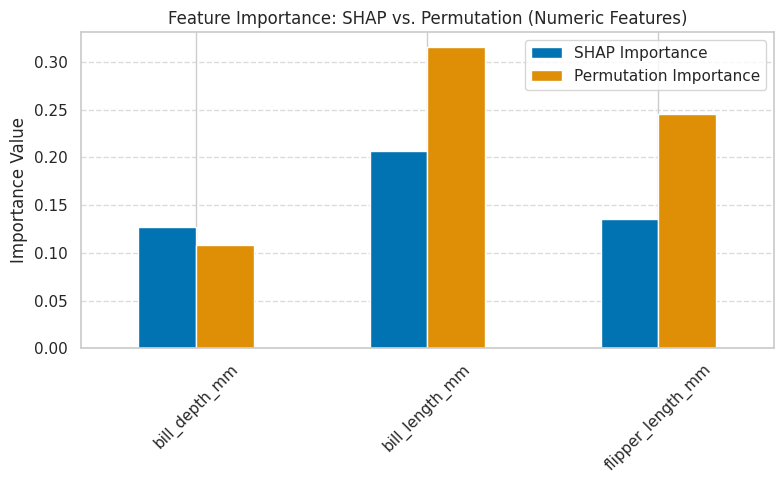

In [63]:
import matplotlib.pyplot as plt

# TODO(exercise 4): compute mean absolute SHAP value per feature (average
# over samples and classes), compare its ranking to perm_importance
# (restricted to num_features), and plot both side by side.

# Starter scaffold (already runs as-is) -- extend it below:
shap_importance = pd.Series(
    np.abs(shap_values.values).mean(axis=(0, 2)), index=num_features  # One global importance number per feature
).sort_values(ascending=False)
print("SHAP global importance (numeric features):")
print(shap_importance)

# TODO: pull perm_importance.loc[num_features] from Section 2, rank both,
# and compare (a simple pd.DataFrame with both rank columns is enough).

# create a data frmae to compare shap_importance and perm_importance.loc[num_features]
comparison_df = pd.DataFrame({
    'SHAP Importance': shap_importance,
    'Permutation Importance': perm_importance.loc[num_features]
})
print(comparison_df)

# Make a plot to compare both
fig, ax = plt.subplots(figsize=(8, 5))
comparison_df.plot.bar(ax=ax, rot=45)
ax.set_title('Feature Importance: SHAP vs. Permutation (Numeric Features)')
ax.set_ylabel('Importance Value')
ax.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

ANSWER: Bothe agree on the ranking, but give different relative importance to flipper_length

GEMINI: Both methods largely agree on the **ranking** of the features, identifying `bill_length_mm`, `flipper_length_mm`, and `bill_depth_mm` as important, in that order. However, they **disagree significantly on the magnitude** of their importance. Permutation Importance assigns much higher values to `bill_length_mm` and `flipper_length_mm` compared to SHAP.

This discrepancy can be attributed to how each method handles **correlated features**. Permutation importance, by permuting one feature at a time, may understate the importance of individual features if they are highly correlated (the model can still rely on the other correlated features). Conversely, SHAP values, being based on a game-theoretic approach, distribute the importance more fairly among correlated features. In this case, `bill_length_mm` and `flipper_length_mm` are likely correlated, and SHAP appears to split the credit between them more evenly, leading to lower individual SHAP values than the Permutation Importance, which measures the drop in performance when one feature is removed (while the other correlated feature remains intact).

---
## Recap, and on to Part 2

Four methods, one dataset, four different pitfalls:

| Method | Answers | Model-agnostic? | Main pitfall |
|---|---|---|---|
| Tree importance | What did *this tree model* lean on? | No | Cardinality/correlation bias |
| Permutation importance | How much does scrambling *this feature* hurt performance? | Yes | Correlated features share blame; expensive |
| PDP / ICE | How does the prediction change as *this feature* varies? | Yes | Averaging hides interactions; extrapolation |
| SHAP | How much did *this feature* contribute to *this prediction*? | Depends on explainer | Explains the model, not the world |

Three of these four methods -- permutation importance, PDP/ICE, and SHAP --
are **perturbation-based**: they probe the model with different inputs
(permuted, varied one at a time, or game-theoretically combined) and observe
how the output responds, treating the model itself as a black box. Tree
importance is the odd one out: it's read directly off the fitted model's
internal impurity-reduction bookkeeping, never perturbs anything, and only
works for tree-based models.

Part 2 (`02_aifs_sensitivities.ipynb`) applies a fundamentally different,
**gradient-based** approach -- backward/adjoint sensitivities -- to ECMWF's
AIFS operational weather model. If you've worked with adjoint models or 4D-Var
data assimilation in numerical weather prediction, that method will look
familiar.